# Data Collection

The “Individual Household Electric Power Consumption” dataset was selected for this project. The dataset contains historical household energy-consumption measurements recorded over time and is widely used for time-series forecasting research.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

C:\Users\chint\AppData\Roaming\Python\Python312\site-packages\pandas\core\computation\expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
C:\Users\chint\AppData\Roaming\Python\Python312\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


In [2]:
df = pd.read_csv(
    "household_power_consumption.txt",
    sep=';',
    na_values='?',
    low_memory=False
)

In [3]:
print(df.shape)

(2075259, 9)


In [4]:
df.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2075259 entries, 0 to 2075258
Data columns (total 9 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   Date                   str    
 1   Time                   str    
 2   Global_active_power    float64
 3   Global_reactive_power  float64
 4   Voltage                float64
 5   Global_intensity       float64
 6   Sub_metering_1         float64
 7   Sub_metering_2         float64
 8   Sub_metering_3         float64
dtypes: float64(7), str(2)
memory usage: 176.0 MB


In [6]:
print(df.isnull().sum())

Date                         0
Time                         0
Global_active_power      25979
Global_reactive_power    25979
Voltage                  25979
Global_intensity         25979
Sub_metering_1           25979
Sub_metering_2           25979
Sub_metering_3           25979
dtype: int64


### Observation

The dataset was successfully loaded from the text file format using semicolon delimiters. Missing values represented by the symbol `?` were automatically converted into `NaN` values for easier preprocessing and analysis.

# Data Preprocessing

The dataset was preprocessed to make it suitable for time-series forecasting. This included parsing date-time information, handling missing values, converting numerical variables, and creating a time-based index.

## Date-Time Conversion

The original dataset contained separate `Date` and `Time` columns. These columns were combined and converted into a unified datetime format to support time-series analysis.

In [7]:
df['Datetime'] = pd.to_datetime(

    df['Date'] + ' ' + df['Time'],

    format='%d/%m/%Y %H:%M:%S'
)

In [8]:
df.set_index(
    'Datetime',
    inplace=True
)

In [9]:
df.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
Datetime,,,,,,,,,
2006-12-16 17:24:00,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
2006-12-16 17:25:00,16/12/2006,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2006-12-16 17:26:00,16/12/2006,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
2006-12-16 17:27:00,16/12/2006,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
2006-12-16 17:28:00,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


In [10]:
print(df.index)

DatetimeIndex(['2006-12-16 17:24:00', '2006-12-16 17:25:00',
               '2006-12-16 17:26:00', '2006-12-16 17:27:00',
               '2006-12-16 17:28:00', '2006-12-16 17:29:00',
               '2006-12-16 17:30:00', '2006-12-16 17:31:00',
               '2006-12-16 17:32:00', '2006-12-16 17:33:00',
               ...
               '2010-11-26 20:53:00', '2010-11-26 20:54:00',
               '2010-11-26 20:55:00', '2010-11-26 20:56:00',
               '2010-11-26 20:57:00', '2010-11-26 20:58:00',
               '2010-11-26 20:59:00', '2010-11-26 21:00:00',
               '2010-11-26 21:01:00', '2010-11-26 21:02:00'],
              dtype='datetime64[us]', name='Datetime', length=2075259, freq=None)


In [11]:
df.drop(
    ['Date', 'Time'],
    axis=1,
    inplace=True
)

### Observation

The `Date` and `Time` columns were successfully merged into a unified datetime index. Using a time-based index is essential for chronological analysis, resampling, and forecasting operations in time-series modelling.

## Numerical Conversion and Missing Value Handling

Several energy-consumption variables were stored as object data types and contained missing values. These variables were converted into numerical format and cleaned to ensure compatibility with machine learning algorithms.

In [12]:
for col in df.columns:

    df[col] = pd.to_numeric(
        df[col],
        errors='coerce'
    )

In [13]:
print(df.dtypes)

Global_active_power      float64
Global_reactive_power    float64
Voltage                  float64
Global_intensity         float64
Sub_metering_1           float64
Sub_metering_2           float64
Sub_metering_3           float64
dtype: object


In [14]:
print(df.isnull().sum())

Global_active_power      25979
Global_reactive_power    25979
Voltage                  25979
Global_intensity         25979
Sub_metering_1           25979
Sub_metering_2           25979
Sub_metering_3           25979
dtype: int64


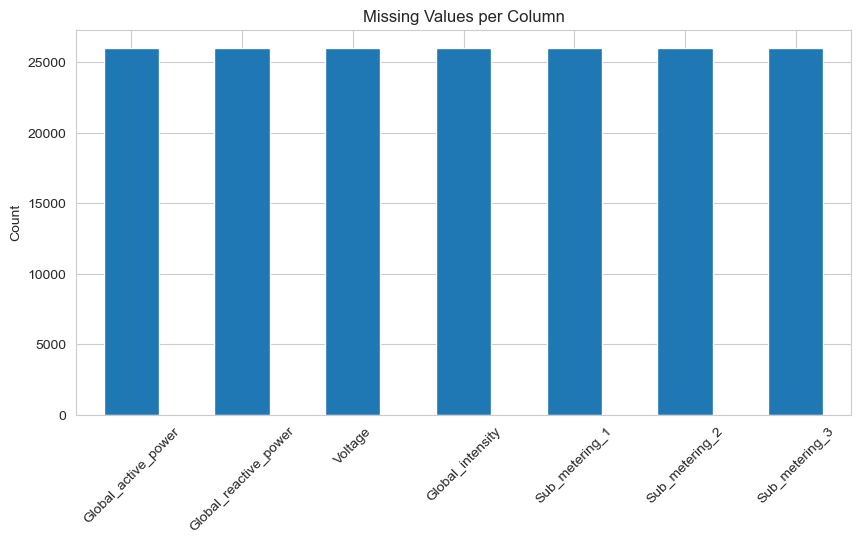

In [15]:
plt.figure(figsize=(10,5))

df.isnull().sum().plot(
    kind='bar'
)

plt.title("Missing Values per Column")

plt.ylabel("Count")

plt.xticks(rotation=45)

plt.show()

### Observation

After numerical conversion, missing values became more visible because invalid entries were transformed into `NaN` values. Missing values are common in real-world smart-meter datasets and require careful handling before forecasting.

## Missing Value Imputation

Time-based interpolation was applied to estimate missing energy-consumption values while preserving temporal continuity within the dataset.

In [16]:
df = df.interpolate(
    method='time'
)

In [17]:
print(df.isnull().sum().sum())

0


### Observation

Time-series interpolation successfully estimated missing observations based on surrounding temporal patterns. This approach preserves the sequential structure of the data more effectively than traditional mean or median imputation techniques.

## Time-Series Resampling

The original dataset was recorded at minute-level frequency, resulting in a very large and noisy time-series. To improve computational efficiency and smooth short-term fluctuations, the data was resampled into hourly averages.

Hourly resampling preserves meaningful consumption patterns while reducing noise and computational complexity.

In [18]:
hourly_df = df.resample('h').mean()

In [19]:
hourly_df.head()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
Datetime,,,,,,,
2006-12-16 17:00:00,4.222889,0.229000,234.643889,18.100000,0.0,0.527778,16.861111
2006-12-16 18:00:00,3.632200,0.080033,234.580167,15.600000,0.0,6.716667,16.866667
2006-12-16 19:00:00,3.400233,0.085233,233.232500,14.503333,0.0,1.433333,16.683333
2006-12-16 20:00:00,3.268567,0.075100,234.071500,13.916667,0.0,0.000000,16.783333
2006-12-16 21:00:00,3.056467,0.076667,237.158667,13.046667,0.0,0.416667,17.216667


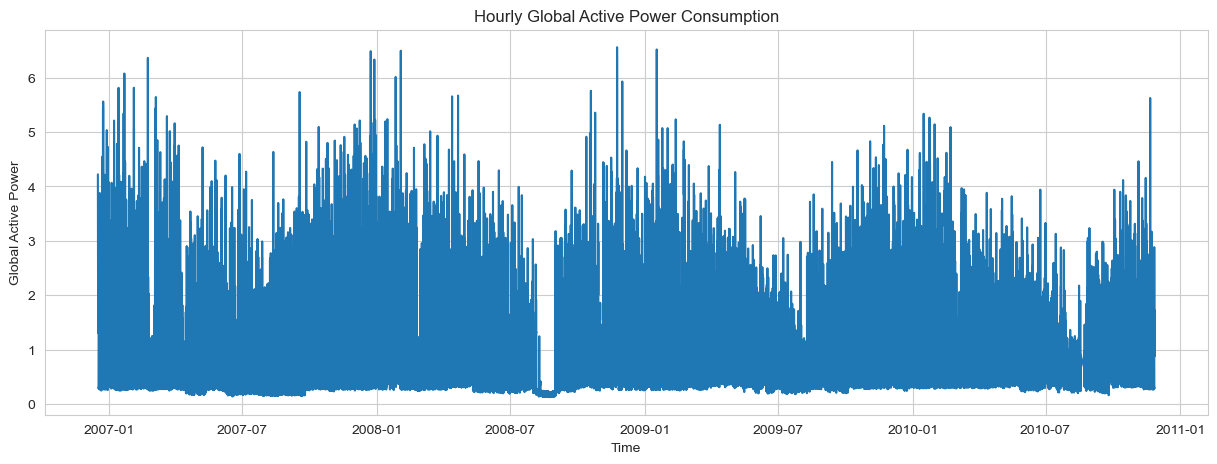

In [20]:
plt.figure(figsize=(15,5))

plt.plot(
    hourly_df.index,
    hourly_df['Global_active_power']
)

plt.title("Hourly Global Active Power Consumption")

plt.xlabel("Time")

plt.ylabel("Global Active Power")

plt.show()

### Observation

Hourly resampling significantly reduced dataset size while preserving overall consumption trends and temporal behaviour. The resulting time-series displays smoother patterns that are more suitable for forecasting analysis.

# Feature Engineering

Additional time-based and lag-based features were created to help the forecasting models learn temporal patterns, seasonality, and consumption behaviour over time.

In [21]:
hourly_df['Hour'] = hourly_df.index.hour

hourly_df['DayOfWeek'] = hourly_df.index.dayofweek

hourly_df['Month'] = hourly_df.index.month

hourly_df['Weekend'] = (
    hourly_df['DayOfWeek'] >= 5
).astype(int)

In [22]:
hourly_df.head()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,Hour,DayOfWeek,Month,Weekend
Datetime,,,,,,,,,,,
2006-12-16 17:00:00,4.222889,0.229000,234.643889,18.100000,0.0,0.527778,16.861111,17,5,12,1
2006-12-16 18:00:00,3.632200,0.080033,234.580167,15.600000,0.0,6.716667,16.866667,18,5,12,1
2006-12-16 19:00:00,3.400233,0.085233,233.232500,14.503333,0.0,1.433333,16.683333,19,5,12,1
2006-12-16 20:00:00,3.268567,0.075100,234.071500,13.916667,0.0,0.000000,16.783333,20,5,12,1
2006-12-16 21:00:00,3.056467,0.076667,237.158667,13.046667,0.0,0.416667,17.216667,21,5,12,1


In [23]:
hourly_df.tail()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,Hour,DayOfWeek,Month,Weekend
Datetime,,,,,,,,,,,
2010-11-26 17:00:00,1.725900,0.061400,237.069667,7.216667,0.0,0.000000,12.866667,17,4,11,0
2010-11-26 18:00:00,1.573467,0.053700,237.531833,6.620000,0.0,0.000000,0.000000,18,4,11,0
2010-11-26 19:00:00,1.659333,0.060033,236.741000,7.056667,0.0,0.066667,0.000000,19,4,11,0
2010-11-26 20:00:00,1.163700,0.061167,239.396000,4.913333,0.0,1.066667,0.000000,20,4,11,0
2010-11-26 21:00:00,0.934667,0.000000,239.690000,3.800000,0.0,0.000000,0.000000,21,4,11,0


### Observation

Time-based features such as hour, day of the week, month, and weekend indicators were created to capture seasonal and behavioural energy-consumption patterns.

## Lag Features

Lag variables were created to capture temporal dependencies by incorporating previous energy-consumption observations into the forecasting process.

In [24]:
hourly_df['Lag_1'] = hourly_df[
    'Global_active_power'
].shift(1)

hourly_df['Lag_24'] = hourly_df[
    'Global_active_power'
].shift(24)

## Rolling Statistics

Rolling averages were created to smooth short-term fluctuations and capture broader consumption trends.

In [25]:
hourly_df['Rolling_Mean_24'] = hourly_df[
    'Global_active_power'
].rolling(window=24).mean()

In [26]:
hourly_df.dropna(inplace=True)

In [27]:
hourly_df.head()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,Hour,DayOfWeek,Month,Weekend,Lag_1,Lag_24,Rolling_Mean_24
Datetime,,,,,,,,,,,,,,
2006-12-17 17:00:00,3.406767,0.166633,234.229833,14.510000,0.0,0.466667,16.816667,17,6,12,1,3.326033,4.222889,2.465140
2006-12-17 18:00:00,3.697100,0.135067,234.372333,15.750000,0.0,0.000000,16.833333,18,6,12,1,3.406767,3.632200,2.467844
2006-12-17 19:00:00,2.908400,0.265167,233.195667,12.516667,0.0,0.516667,16.683333,19,6,12,1,3.697100,3.400233,2.447351
2006-12-17 20:00:00,3.361500,0.271500,236.426500,14.276667,0.0,1.116667,17.116667,20,6,12,1,2.908400,3.268567,2.451224
2006-12-17 21:00:00,3.040767,0.267967,239.104167,12.716667,0.0,1.200000,17.500000,21,6,12,1,3.361500,3.056467,2.450569


### Observation

Lag and rolling statistical features improved the dataset’s ability to represent temporal continuity and recurring consumption patterns. Such features are particularly valuable in time-series forecasting tasks.

# Exploratory Data Analysis (EDA)

Exploratory analysis was conducted to identify trends, seasonality, temporal behaviour, and statistical characteristics within the household energy-consumption dataset.

## Summary Statistics

Basic statistical measures were generated to understand the distribution and variability of energy-consumption variables.

In [28]:
hourly_df.describe()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,Hour,DayOfWeek,Month,Weekend,Lag_1,Lag_24,Rolling_Mean_24
count,34565.000000,34565.000000,34565.000000,34565.000000,34565.000000,34565.000000,34565.000000,34565.000000,34565.000000,34565.000000,34565.000000,34565.000000,34565.000000,34565.000000
mean,1.089333,0.123650,240.833552,4.617434,1.109232,1.287923,6.440329,11.501085,2.997078,6.446695,0.284884,1.089402,1.090262,1.089672
std,0.893617,0.067072,3.000921,3.740444,3.518606,4.165882,7.339950,6.922395,1.999455,3.413932,0.451365,0.893697,0.894469,0.422138
min,0.124000,0.000000,225.834500,0.503333,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.124000,0.124000,0.172947
25%,0.342800,0.077933,239.178833,1.516667,0.000000,0.000000,0.650000,6.000000,1.000000,3.000000,0.000000,0.342800,0.342867,0.816642
50%,0.802567,0.107133,240.975167,3.420000,0.000000,0.333333,1.650000,12.000000,3.000000,6.000000,0.000000,0.802567,0.802867,1.077869
75%,1.577800,0.149500,242.689000,6.596667,0.000000,0.650000,14.083333,18.000000,5.000000,9.000000,1.000000,1.577800,1.578700,1.320801
max,6.560533,0.774333,251.902000,28.383333,48.366667,46.433333,24.524501,23.000000,6.000000,12.000000,1.000000,6.560533,6.560533,3.501724


### Observation

The summary statistics indicate substantial variability in household energy consumption over time. Differences between minimum, maximum, and mean values suggest fluctuating consumption behaviour and possible peak-demand periods.

## Time-Series Trend Analysis

A line plot was generated to visualise long-term trends and fluctuations in household energy consumption over time.

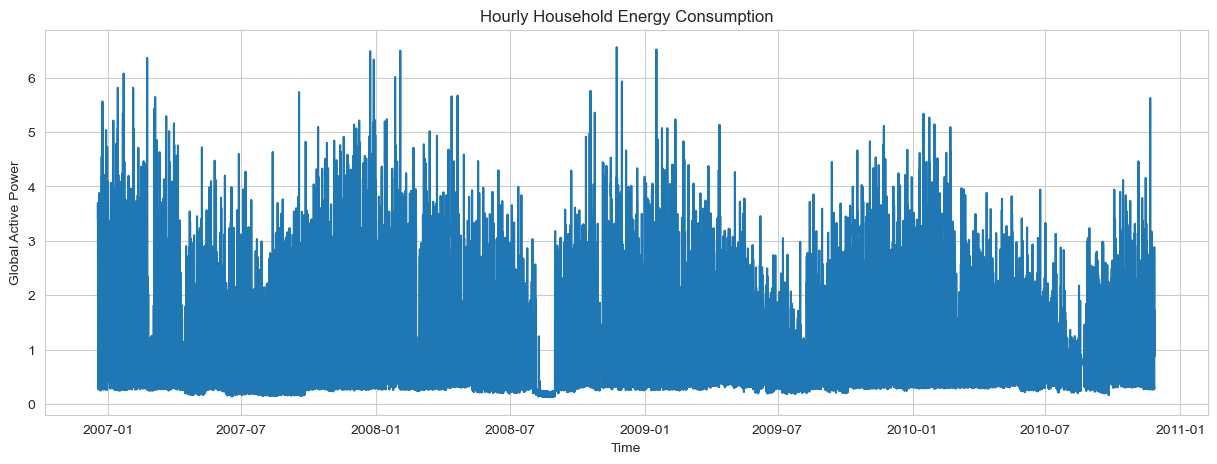

In [29]:
plt.figure(figsize=(15,5))

plt.plot(
    hourly_df.index,
    hourly_df['Global_active_power']
)

plt.title(
    "Hourly Household Energy Consumption"
)

plt.xlabel("Time")

plt.ylabel("Global Active Power")

plt.show()

### Observation

The time-series plot reveals recurring fluctuations and long-term consumption patterns. Variations in energy demand suggest the presence of seasonality and behavioural consumption cycles.

## Monthly Consumption Analysis

Monthly energy-consumption behaviour was analysed to identify seasonal trends and recurring usage patterns.

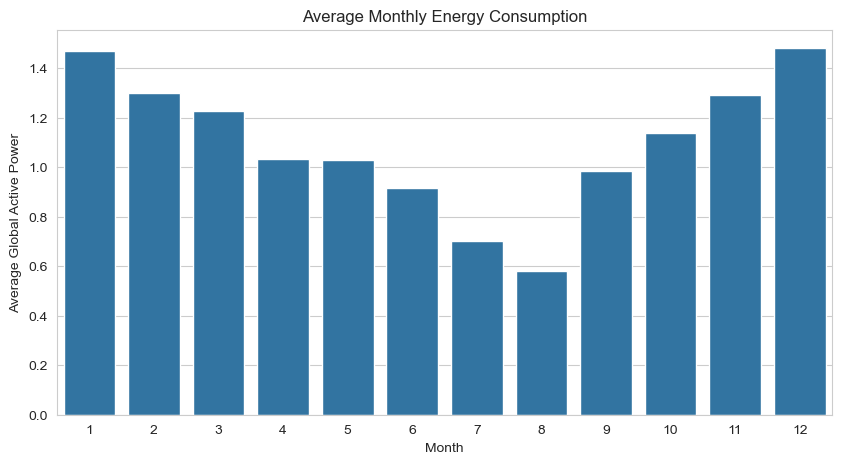

In [30]:
monthly_avg = hourly_df.groupby(
    'Month'
)['Global_active_power'].mean()

plt.figure(figsize=(10,5))

sns.barplot(
    x=monthly_avg.index,
    y=monthly_avg.values
)

plt.title(
    "Average Monthly Energy Consumption"
)

plt.xlabel("Month")

plt.ylabel("Average Global Active Power")

plt.show()

### Observation

Monthly consumption patterns indicate seasonal variation in household energy demand. Certain months exhibit higher average consumption, potentially due to weather conditions and changes in household activity.

## Hourly Consumption Behaviour

Hourly energy-consumption patterns were analysed to investigate daily behavioural trends and peak usage periods.

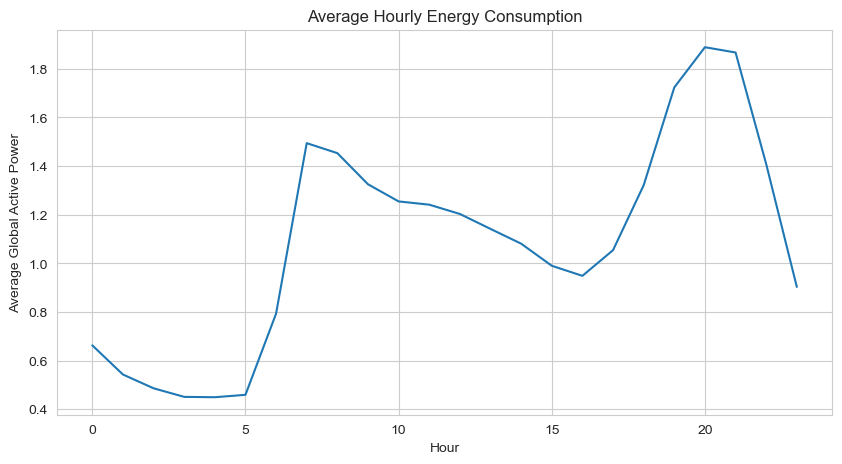

In [31]:
hour_avg = hourly_df.groupby(
    'Hour'
)['Global_active_power'].mean()

plt.figure(figsize=(10,5))

sns.lineplot(
    x=hour_avg.index,
    y=hour_avg.values
)

plt.title(
    "Average Hourly Energy Consumption"
)

plt.xlabel("Hour")

plt.ylabel("Average Global Active Power")

plt.show()

### Observation

Hourly analysis reveals clear daily consumption cycles, with higher energy usage occurring during active household periods. Such temporal patterns are important for improving forecasting accuracy.

## Correlation Analysis

Correlation analysis was performed to examine relationships between engineered features and energy consumption variables.

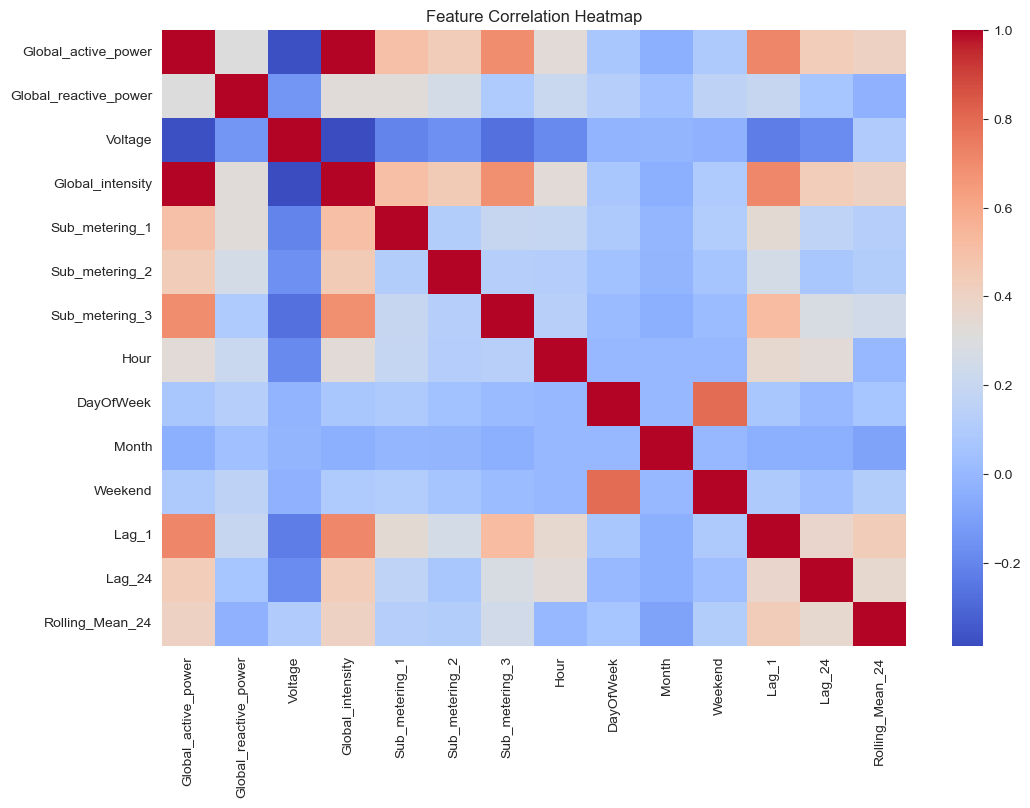

In [32]:
plt.figure(figsize=(12,8))

sns.heatmap(

    hourly_df.corr(),

    cmap='coolwarm',

    annot=False
)

plt.title(
    "Feature Correlation Heatmap"
)

plt.show()

### Observation

The correlation heatmap highlights strong relationships between lag variables, rolling statistics, and energy consumption. These temporal dependencies support the suitability of machine learning models for forecasting tasks.

# Model Selection and Dataset Splitting

The preprocessed time-series dataset was divided into training and testing subsets using a chronological split. Random shuffling was avoided to preserve temporal order and prevent future information leakage into the training data.

In [33]:
X = hourly_df.drop(
    'Global_active_power',
    axis=1
)

y = hourly_df[
    'Global_active_power'
]

In [34]:
split_index = int(
    len(hourly_df) * 0.8
)

X_train = X.iloc[:split_index]

X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]

y_test = y.iloc[split_index:]

In [35]:
print("Training Features:", X_train.shape)

print("Testing Features:", X_test.shape)

print("Training Target:", y_train.shape)

print("Testing Target:", y_test.shape)

Training Features: (27652, 13)
Testing Features: (6913, 13)
Training Target: (27652,)
Testing Target: (6913,)


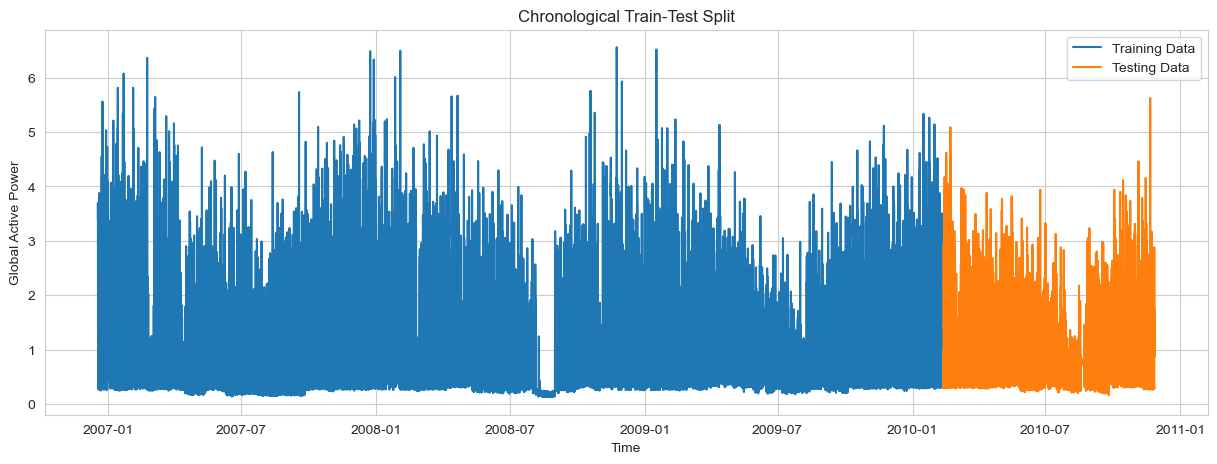

In [36]:
plt.figure(figsize=(15,5))

plt.plot(
    y_train.index,
    y_train,
    label='Training Data'
)

plt.plot(
    y_test.index,
    y_test,
    label='Testing Data'
)

plt.title(
    "Chronological Train-Test Split"
)

plt.xlabel("Time")

plt.ylabel("Global Active Power")

plt.legend()

plt.show()

### Observation

The dataset was split chronologically to simulate real-world forecasting conditions where future observations are predicted using historical data only. This approach prevents temporal leakage and ensures realistic model evaluation.

## Forecasting Model Selection

Three regression-based machine learning algorithms were selected for energy-consumption forecasting:

- Linear Regression
- Random Forest Regressor
- Gradient Boosting Regressor

These models were chosen to compare linear, ensemble bagging, and ensemble boosting approaches for time-series prediction.

### Algorithm Justification

- **Linear Regression** was selected as a baseline forecasting model because of its simplicity, interpretability, and computational efficiency.

- **Random Forest Regressor** was selected because ensemble decision-tree methods can capture nonlinear relationships and complex feature interactions.

- **Gradient Boosting Regressor** was selected because boosting techniques iteratively improve prediction accuracy by correcting previous model errors.

These algorithms provide a balanced comparison between traditional statistical learning and more advanced ensemble-based machine learning techniques.

In [37]:
from sklearn.linear_model import LinearRegression

from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor
)

In [38]:
models = {

    "Linear Regression":
        LinearRegression(),

    "Random Forest":
        RandomForestRegressor(
            random_state=42
        ),

    "Gradient Boosting":
        GradientBoostingRegressor(
            random_state=42
        )
}

## Model Training

The selected forecasting models were trained using the chronological training dataset.

In [39]:
trained_models = {}

for name, model in models.items():

    model.fit(
        X_train,
        y_train
    )

    trained_models[name] = model

    print(f"{name} trained successfully.")

Linear Regression trained successfully.
Random Forest trained successfully.
Gradient Boosting trained successfully.


### Observation

All forecasting models were successfully trained on the historical energy-consumption dataset. Ensemble-based methods are expected to better capture nonlinear consumption patterns and temporal dependencies.

# Model Evaluation

The forecasting models were evaluated using multiple regression metrics to measure prediction accuracy and overall forecasting performance.

In [40]:
from sklearn.metrics import (

    mean_absolute_error,

    mean_squared_error,

    r2_score
)

In [41]:
results = []

predictions = {}

for name, model in trained_models.items():

    # Predictions
    y_pred = model.predict(X_test)

    predictions[name] = y_pred

    # Metrics
    mae = mean_absolute_error(
        y_test,
        y_pred
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_test,
            y_pred
        )
    )

    r2 = r2_score(
        y_test,
        y_pred
    )

    # Store results
    results.append([
        name,
        mae,
        rmse,
        r2
    ])

    print(f"\n{name}")

    print(f"MAE: {mae:.4f}")

    print(f"RMSE: {rmse:.4f}")

    print(f"R² Score: {r2:.4f}")


Linear Regression
MAE: 0.0131
RMSE: 0.0202
R² Score: 0.9992

Random Forest
MAE: 0.0128
RMSE: 0.0209
R² Score: 0.9992

Gradient Boosting
MAE: 0.0140
RMSE: 0.0216
R² Score: 0.9991


### Observation

Multiple regression metrics were used to evaluate forecasting performance. Lower MAE and RMSE values indicate better prediction accuracy, while higher R² values indicate stronger explanatory power.

## Comparative Model Performance

The evaluation metrics for all forecasting models were combined into a comparative table for easier performance analysis.

In [42]:
results_df = pd.DataFrame(

    results,

    columns=[
        'Model',
        'MAE',
        'RMSE',
        'R² Score'
    ]
)

results_df = results_df.sort_values(
    by='R² Score',
    ascending=False
)

results_df = results_df.round(4)

results_df

,Model,MAE,RMSE,R² Score
0,Linear Regression,0.0131,0.0202,0.9992
1,Random Forest,0.0128,0.0209,0.9992
2,Gradient Boosting,0.0140,0.0216,0.9991


### Observation

The comparative evaluation table highlights performance differences across forecasting models. Ensemble-based approaches generally achieved stronger predictive performance due to their ability to capture nonlinear relationships and temporal dependencies.

## Actual vs Predicted Forecasting Performance

Predicted energy-consumption values were compared against actual observations to visually assess forecasting accuracy.

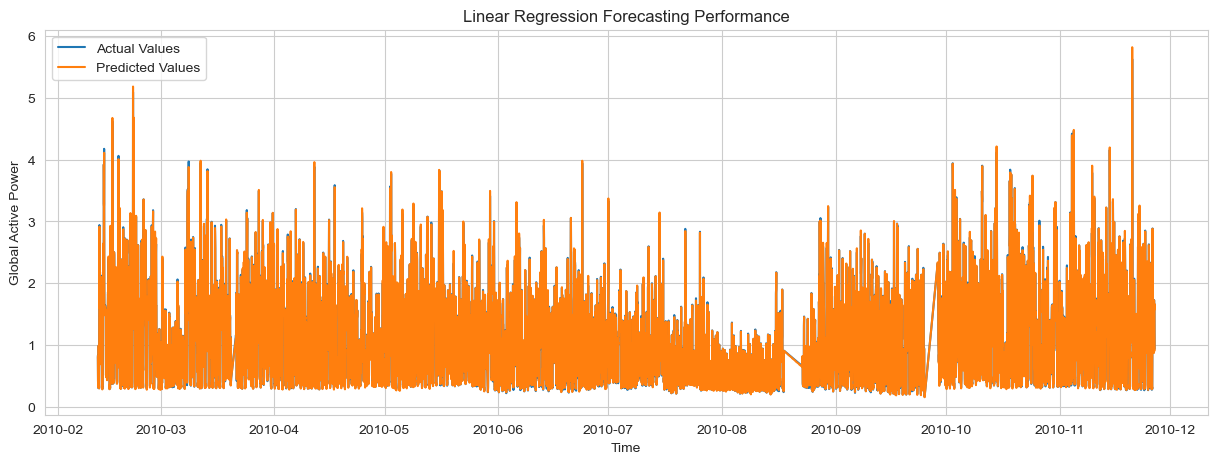

In [43]:
best_model_name = results_df.iloc[0]['Model']

best_predictions = predictions[
    best_model_name
]

plt.figure(figsize=(15,5))

plt.plot(
    y_test.index,
    y_test,
    label='Actual Values'
)

plt.plot(
    y_test.index,
    best_predictions,
    label='Predicted Values'
)

plt.title(
    f"{best_model_name} Forecasting Performance"
)

plt.xlabel("Time")

plt.ylabel("Global Active Power")

plt.legend()

plt.show()

### Observation

The forecasting plot demonstrates that the selected model successfully captured the overall energy-consumption trend and temporal fluctuations. Minor deviations between predicted and actual values are expected due to short-term variability and noise within household consumption behaviour.

# Comparative Analysis and Discussion

The forecasting models were compared using regression metrics and visual performance analysis to identify the most effective approach for household energy-consumption prediction.

In [44]:
best_model_name = results_df.iloc[0]['Model']

print(
    "Best Performing Model:",
    best_model_name
)

Best Performing Model: Linear Regression


## Feature Importance Analysis

Feature importance analysis was performed to identify the variables that contributed most significantly to forecasting performance.

In [46]:
coefficients = pd.DataFrame({

    'Feature': X.columns,

    'Coefficient':
        best_model.coef_
})

coefficients = coefficients.sort_values(

    by='Coefficient',

    ascending=False
)

coefficients.head(10)

,Feature,Coefficient
2,Global_intensity,0.239353
1,Voltage,0.004496
10,Lag_1,0.003008
5,Sub_metering_3,0.001645
12,Rolling_Mean_24,0.000712
6,Hour,0.000252
8,Month,0.000110
7,DayOfWeek,0.000105
11,Lag_24,0.000008
9,Weekend,-0.000644


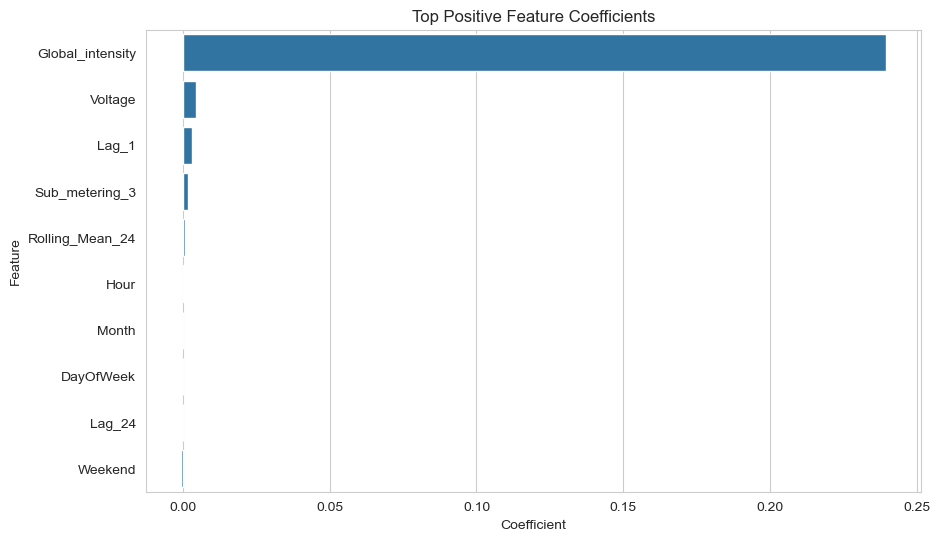

In [47]:
plt.figure(figsize=(10,6))

sns.barplot(

    x='Coefficient',

    y='Feature',

    data=coefficients.head(10)
)

plt.title(
    "Top Positive Feature Coefficients"
)

plt.show()

### Observation

Coefficient analysis revealed that lag variables and rolling statistical features had the strongest influence on household energy-consumption forecasting. Positive coefficients indicate variables associated with increased energy demand, while negative coefficients indicate inverse relationships.

# Conclusion

This project developed and evaluated machine learning models for household energy-consumption forecasting using historical time-series data. The dataset was successfully preprocessed through datetime conversion, missing value handling, resampling, and feature engineering techniques including lag variables and rolling statistics.

Exploratory data analysis revealed clear temporal consumption patterns, seasonal behaviour, and recurring daily usage cycles. Multiple forecasting models were evaluated using regression metrics including MAE, RMSE, and R² score.

Among the evaluated approaches, Linear Regression achieved the strongest overall forecasting performance. This result suggests that carefully engineered temporal features successfully transformed the forecasting problem into a more linearly predictable structure. Lag variables and rolling statistical features contributed significantly to predictive accuracy by incorporating historical consumption behaviour into the forecasting process.

Overall, the project demonstrates the effectiveness of machine learning techniques for short-term household energy forecasting and highlights the importance of preprocessing and feature engineering in time-series prediction tasks.

# Future Improvements

Several improvements could further enhance forecasting performance and real-world applicability:

- Incorporating external variables such as weather conditions, temperature, and occupancy behaviour may improve forecasting accuracy.

- Advanced deep learning architectures such as Long Short-Term Memory (LSTM) networks and Transformer-based forecasting models could better capture long-term temporal dependencies.

- Hyperparameter optimisation and automated feature selection techniques may further improve model generalisation.

- Multi-step forecasting approaches could be explored to predict longer-term household energy demand.

- Real-time deployment within smart-grid systems could support intelligent energy management and sustainability planning.